|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0% ◆ elapsed 297.01ms ◆ remaining 0.00ms
|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0% ◆ elapsed 190.00ms ◆ remaining 0.00ms
|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0% ◆ elapsed 287.05ms ◆ remaining 0.00ms
|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0% ◆ elapsed 100.00ms ◆ remaining 0.00ms
|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0% ◆ elapsed 308.01ms ◆ remaining 0.00ms
|█████████████████████████████████████████████████████████████████████████████████████████████████████████████

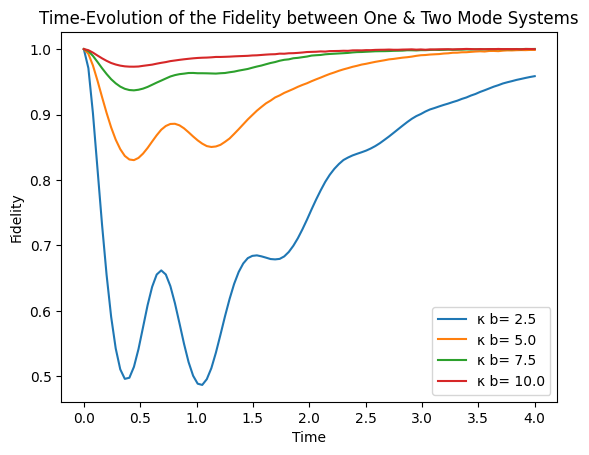

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 15.46it/s]


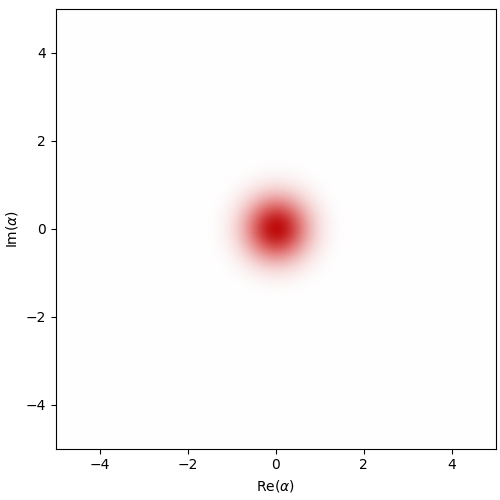

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 16.11it/s]


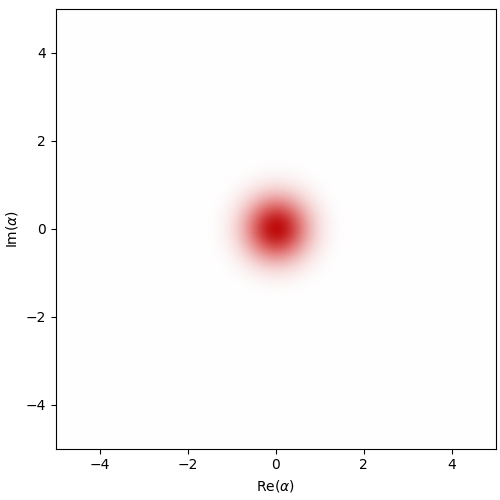

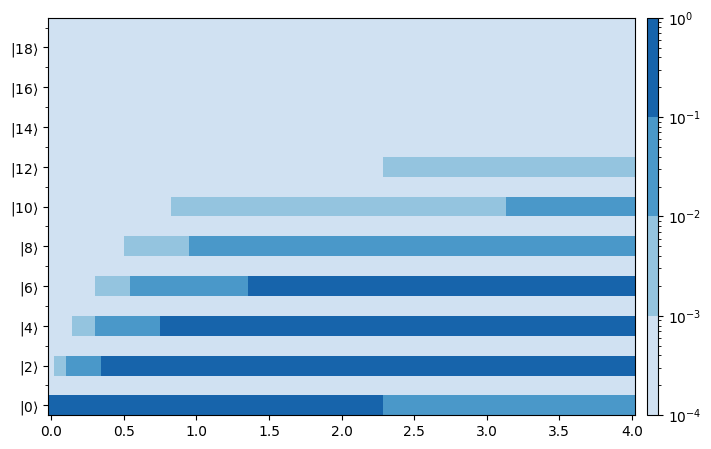

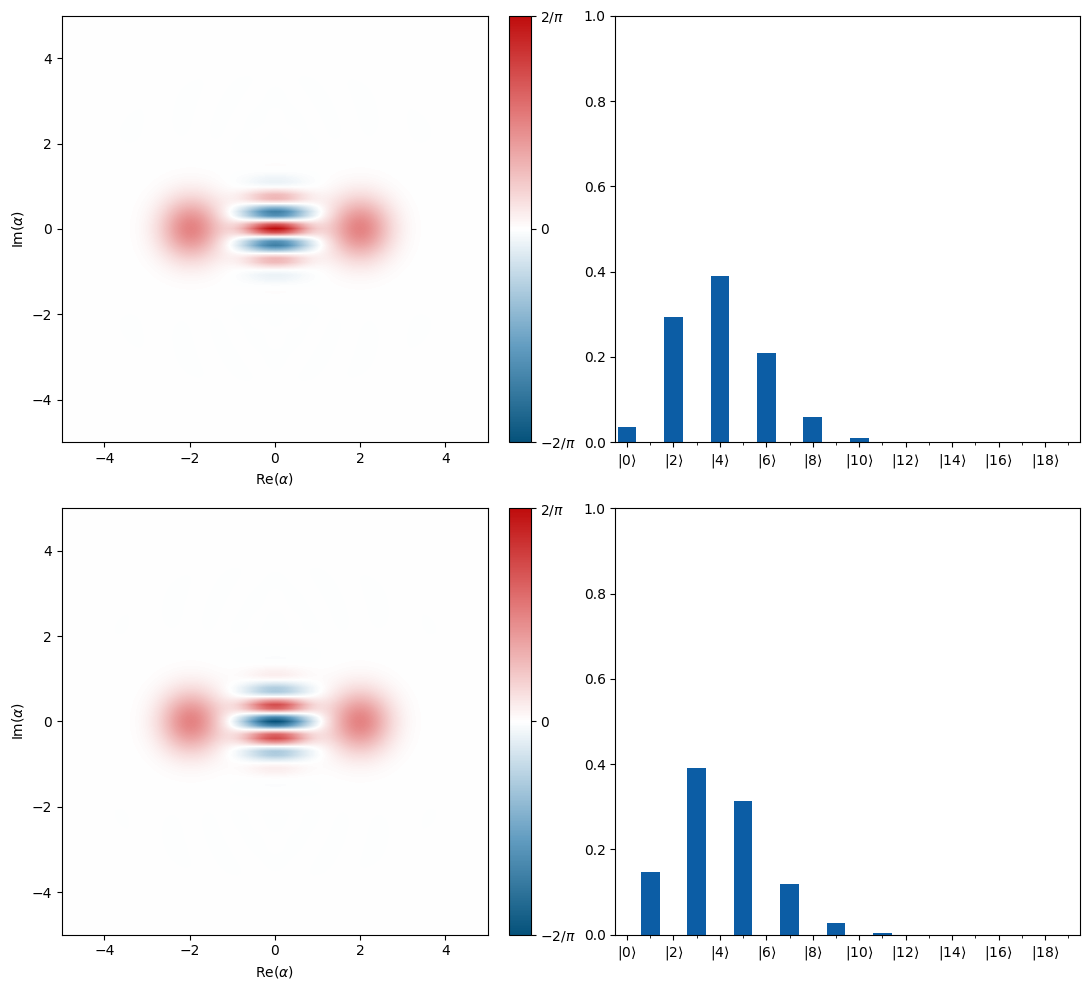

In [5]:
# 1.1 & 1.2

import jax.numpy as jnp
import dynamiqs as dq
import matplotlib.pyplot as plt
from IPython.display import display

# General Info ---------------------------------------------------------------------

# Define the Hilbert space dimensions for each mode
n_a = 20  # Number of Fock states in mode a
n_b = 5   # Number of Fock states in mode b
alpha = 2.0

# Define the parameters for the system
g_2 = 1.0
epsilon_d = -4
kappa_b_arr = [2.5, 5, 7.5, 10]

# Time span for simulation
tsave = jnp.linspace(0, 4, 100)

fidelity_list = []

# Changes the kappa_b constant variable
for kappa_b in kappa_b_arr:
    # Two-Photon ------------------------------------------------------------------------
    
    # Define the annihilation operators for both modes
    two_a, two_b = dq.destroy(n_a, n_b)  # Annihilation operator for mode a, b
    
    # Two-photon exchange Hamiltonian (for interaction between modes a and b)
    H_2ph = (g_2 * two_a.dag() @ two_a.dag() @ two_b) + (g_2 * two_a @ two_a @ two_b.dag())
    
    # Buffer drive Hamiltonian (for mode b)
    H_d = (epsilon_d * two_b) + (epsilon_d * two_b.dag())
    
    # Total Hamiltonian (for the combined system)
    H_total = H_2ph + H_d
    
    # Define the initial state: vacuum state for both modes as a tensor product
    two_psi0 = dq.tensor(dq.fock(n_a, 0), dq.fock(n_b, 0))  # Vacuum state for mode a and b
    
    two_loss_op = jnp.sqrt(kappa_b) * two_b   # Dissipator for the buffer mode
    
    # Solve the system's evolution using the Lindblad master equation
    two_res = dq.mesolve(H_total, [two_loss_op], two_psi0, tsave)
    two_rhoa = dq.ptrace(two_res.states,0)
    
    # One-Photon ------------------------------------------------------------------------
    
    # Define the annihilation operator
    one_a = dq.destroy(n_a)  
    
    # One-photon dissipation rate
    kappa_2 = 4 * jnp.abs(g_2) ** 2 / kappa_b
    alpha_2 = -epsilon_d / g_2
    
    # Zero Hamiltonian (since no Hamiltonian dynamics)
    H = dq.zeros(n_a)
    
    # Define the initial state
    one_psi0 = dq.fock(n_a, 0)
    
    # Define the jump operator
    one_loss_op = jnp.sqrt(kappa_2) * (one_a @ one_a - alpha_2 * dq.eye(n_a))
    
    
    # Solve the system's evolution using the Lindblad master equation
    one_res = dq.mesolve(H, [one_loss_op],one_psi0, tsave) 

    # Append to the Fidelity_List (Compares between the two states)
    fidelity_list.append([dq.fidelity(two_rhoa[i], one_res.states[i]) for i in range(len(one_res.states))])


# Printing ------------------------------------------------------------------------

# Displaying Fidility -------------------------------------------------------------
plt.plot(tsave, fidelity_list[0], label = "\u03BA b= 2.5")
plt.plot(tsave, fidelity_list[1], label = "\u03BA b= 5.0")
plt.plot(tsave, fidelity_list[2], label = "\u03BA b= 7.5")
plt.plot(tsave, fidelity_list[3], label = "\u03BA b= 10.0")
plt.xlabel("Time")
plt.ylabel("Fidelity")
plt.title("Time-Evolution of the Fidelity between One & Two Mode Systems")
plt.legend()
plt.show()

# Important :
# When dealing with higher fidility, we notice how the curves are more straight
# and closer to 1 as we increase kappa_b. This means by increasing kappa_b, making
# the two systems similar. So lower kappa_b makes the code have more error due to 
# a more difference (fidility closer to 0). 


# Displaying Gif of Two & One-Mode Systems ---------------------------------------
display(dq.plot.wigner_gif(two_rhoa))
display(dq.plot.wigner_gif(one_res.states))


# Displaying Even and Odds (One-Mode System) --------------------------------------
#Fock plots over time of memory(mode a) and buffer (mode b)
#x-axis time, y-axis fock states corresponding to different photon states, color intensity relates to population probability of each fock state
dq.plot.fock_evolution(one_res.states, times=tsave, logscale= True)
#Plots of parity of photons in memory
cat_even = dq.unit(dq.coherent(n_a, alpha) + dq.coherent(n_a, -alpha))
cat_odd = dq.unit(dq.coherent(n_a, alpha) - dq.coherent(n_a, -alpha))
fig, ax = plt.subplots(2,2, figsize=(11,10))
dq.plot.wigner(cat_even, ax=ax[0,0]) # plot Wigner of even cat state 
dq.plot.fock(cat_even, ax=ax[0,1]) # plot Fock states of even cat state
dq.plot.wigner(cat_odd, ax=ax[1,0]) # plot Wigner of odd cat state
dq.plot.fock(cat_odd, ax=ax[1,1]) # plot Fock states of odd cat state
plt.tight_layout()
plt.show()

In [ ]:
# 1.3

mport jax.numpy as jnp
import dynamiqs as dq

# Define the Hilbert space dimensions for each mode
n_a = 20  # Number of Fock states in mode a
n_b = 5   # Number of Fock states in mode b
alpha = 3.0 # cat size

omega  = 1.0
kappa_phi = 0.1 # dephasing rate
kappa = 0.2 # single-photon loss rate
na = 15 # Hilbert space truncation

# Define the annihilation operators for both modes
a, b = dq.destroy(n_a, n_b)  # Annihilation operator for mode a, b

# Define the parameters for the system
g_2 = 1.0
epsilon_d = -4
kappa_b = 10

# Two-photon exchange Hamiltonian (for interaction between modes a and b)
H_2ph = (g_2 * a.dag() @ a.dag() @ b) + (g_2 * a @ a @ b.dag())

# Buffer drive Hamiltonian (for mode b)
H_d = (epsilon_d * b) + (epsilon_d * b.dag())

# Total Hamiltonian (for the combined system)
H_total = H_2ph + H_d

# Define the initial state: vacuum state for both modes as a tensor product
psi0 = dq.tensor(dq.fock(n_a, 2), dq.fock(n_b, 2))  # Vacuum state for mode a and b

# Define the jump operator (loss for mode b)
loss_op = jnp.sqrt(kappa_b) * b   # Dissipator for the buffer mode

epsilon_Z = -2.5
TZ = 8
O_hat = a @ a

# # H_additional = dq.tensor(epsilon_Z, O_hat) + dq.tensor(epsilon_Z, O_hat.dag())
# H_additional = epsilon_Z * O_hat + epsilon_Z * O_hat.dag()

# Time-dependent modulation function
def modulation(t):
    #return 1.0;
    return jnp.sin(jnp.pi * t / (12 * TZ))

# Additional Hamiltonian for Zeno rotation (time-dependent)
H_additional = dq.modulated(modulation, epsilon_Z * (O_hat + O_hat.dag()))


H = H_total + H_additional

tsave = jnp.linspace(0, 4*TZ, 100)

# must use mesolve
#res = dq.mesolve(H, [loss_op], psi0, tsave)
res = dq.mesolve(omega*a.dag()@a, [loss_op], psi0, tsave)

# Plot the Wigner function of mode a using the states obtained from mesolve
#dq.plot.wigner_gif(res.states)

rhoa = dq.ptrace(res.states,0)
dq.plot.wigner_gif(rhoa)

In [ ]:
# 1.4
import jax
import jax.numpy as jnp
import optax
import dynamiqs as dq
import matplotlib.pyplot as plt

# Define the Hilbert space dimensions
a_dim, b_dim = 20, 5

a, b = dq.destroy(a_dim, b_dim)  # Annihilation operators

g_2, kappa_b = 1.0, 10.0  # System parameters
T, num_bins = 3.0, 10  # Evolution time and number of bins for ε_d(t)

def simulate_dynamics(epsilon_d_vals):
    """Simulate the system dynamics for given ε_d(t) values."""
    dt = T / num_bins
    tlist = jnp.linspace(0, T, num_bins)
    
    rho_ini = dq.tensor(dq.fock(a_dim, 0), dq.fock(b_dim, 0))
    L_b = jnp.sqrt(kappa_b) * b  # Dissipator
    
    rho_t = rho_ini
    for i in range(num_bins):
        H_drive = (epsilon_d_vals[i] * b) + (epsilon_d_vals[i] * b.dag())
        H_total = (g_2 * a.dag() @ a.dag() @ b) + (g_2 * a @ a @ b.dag()) + H_drive
        rho_t = dq.mesolve(H_total, [L_b], rho_t, jnp.array([0, dt])).states[-1]
    
    rho_a = dq.ptrace(rho_t, 0)  # Trace out buffer mode
    photon_number = jnp.real(jnp.trace(rho_a @ (a.dag() @ a)))
    return photon_number

def loss_fn(epsilon_d_vals):
    """Loss function to minimize the deviation from the target photon number."""
    photon_number = simulate_dynamics(epsilon_d_vals)
    return (photon_number - 4.0) ** 2  # Target α² = 4

# Initialize parameters
key = jax.random.PRNGKey(0)
epsilon_d_init = jax.random.uniform(key, (num_bins,), minval=-5.0, maxval=5.0)
optimizer = optax.adam(learning_rate=0.1)
opt_state = optimizer.init(epsilon_d_init)

def update(params, opt_state):
    """Perform one optimization step."""
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

# Optimize ε_d(t)
n_iters = 200
epsilon_d_vals = epsilon_d_init
loss_history = []

for _ in range(n_iters):
    epsilon_d_vals, opt_state, loss = update(epsilon_d_vals, opt_state)
    loss_history.append(loss)

# Plot results
plt.figure(figsize=(6, 4))
plt.plot(jnp.linspace(0, T, num_bins), epsilon_d_vals, marker='o', linestyle='-')
plt.xlabel('Time')
plt.ylabel('$\epsilon_d(t)$')
plt.title('Optimized $\epsilon_d(t)$')
plt.show()


In [ ]:
# 2.1
# This is section is not fully developed!
import dynamiqs as dq
import jax.numpy as jnp
import math

omega_a =  5.26 * math.pi # eigenfrequency of the mode a (memory)
omega_b = 7.70 * math.pi # eigenfrequency of the mode b (buffer)
psi_a = 0.06
psi_b = 0.29
Egg_j = 42.76
Delta_Egg_j = 0.47
omega_d = 7.623 * math.pi # resonant drive
omega_p = 2.891 * math.pi
epsilon_d = -3.815 * math.pi # drive strength
epsilon_p = 0.122

na = 20 # Hilbert space size
nb = 5

a, b = dq.destroy(na, nb) # annihilation operator
t = 1

psi0 = dq.tensor(dq.coherent(na, 0.0), dq.coherent(nb, 0.0)) # start in the vaccum

H_0 = omega_a * a.dag() @ a + omega_b * b.dag() @ b
H_ATS = -2 * Egg_j * jnp.sin(epsilon_p * jnp.cos(omega_p * t)) * jnp.sin(psi_a) + 2 * Delta_Egg_j * jnp.cos(epsilon_p * jnp.cos(omega_p * t)) * jnp.cos(psi_b)
H_d = 2 * epsilon_d * jnp.cos(omega_d * t) * (b + b.dag())


tsave = jnp.linspace(0, 20, 400)

res = dq.mesolve(H, [jnp.sqrt(kappa_a)*a], psi0, tsave)

dq.plot.wigner_gif(res.states, fps = 24)